In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

print("Demand forecasting environment initialized successfully.")

Demand forecasting environment initialized successfully.


In [2]:
BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

train = pd.read_csv(
    PROCESSED_DIR / "train_daily_demand.csv"
)

validation = pd.read_csv(
    PROCESSED_DIR / "validation_daily_demand.csv"
)

train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

print("Training shape:", train.shape)
print("Validation shape:", validation.shape)

print("\nTraining period:")
print(train["date"].min(), "to", train["date"].max())

print("\nValidation period:")
print(validation["date"].min(), "to", validation["date"].max())

Training shape: (1913, 2)
Validation shape: (28, 2)

Training period:
2011-01-29 00:00:00 to 2016-04-24 00:00:00

Validation period:
2016-04-25 00:00:00 to 2016-05-22 00:00:00


In [3]:
prophet_train = train[[
    "date",
    "units_sold"
]].copy()

prophet_train.columns = [
    "ds",
    "y"
]

print(prophet_train.head())
print(prophet_train.shape)

          ds      y
0 2011-01-29  32631
1 2011-01-30  31749
2 2011-01-31  23783
3 2011-02-01  25412
4 2011-02-02  19146
(1913, 2)


In [9]:
import sys
print(sys.executable)

c:\Program Files\Python311\python.exe


In [10]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "prophet"
])

0

In [11]:
from prophet import Prophet

print("Prophet imported successfully!")

Prophet imported successfully!


In [ ]:
from prophet import Prophet

# Create Prophet model
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train model
model.fit(prophet_train)

print("Prophet model trained successfully.")


18:48:45 - cmdstanpy - INFO - Chain [1] start processing
18:48:48 - cmdstanpy - INFO - Chain [1] done processing


Prophet model trained successfully.


In [13]:
# Create future dates
future = model.make_future_dataframe(
    periods=len(validation),
    freq="D"
)

# Generate forecast
forecast = model.predict(future)

print("Forecast generated successfully.")
print(forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(28))

Forecast generated successfully.
             ds          yhat    yhat_lower    yhat_upper
1913 2016-04-25  39473.600682  35060.373535  44168.891464
1914 2016-04-26  36938.979958  32753.518858  41505.907325
1915 2016-04-27  36532.040350  32406.417544  41134.450680
1916 2016-04-28  36681.098304  32241.162047  40707.602896
1917 2016-04-29  40658.340443  35848.329147  44974.246542
1918 2016-04-30  47978.490593  43344.898091  52248.733607
1919 2016-05-01  47522.052296  43098.411375  52065.009410
1920 2016-05-02  39231.942552  34471.667284  43861.393896
1921 2016-05-03  36712.862325  32405.050977  41047.620010
1922 2016-05-04  36321.937843  31700.263107  40698.194164
1923 2016-05-05  36487.835550  32057.307850  40740.921701
1924 2016-05-06  40483.147904  35989.959119  44809.419360
1925 2016-05-07  47823.040457  43582.894861  52129.353461
1926 2016-05-08  47388.472668  43087.631475  51947.466664
1927 2016-05-09  39122.808940  34599.028434  43669.417916
1928 2016-05-10  36631.166241  32364.36

In [14]:
prophet_validation = forecast[
    ["ds", "yhat"]
].tail(28).copy()

prophet_validation.columns = [
    "date",
    "forecast"
]

print(prophet_validation)

           date      forecast
1913 2016-04-25  39473.600682
1914 2016-04-26  36938.979958
1915 2016-04-27  36532.040350
1916 2016-04-28  36681.098304
1917 2016-04-29  40658.340443
1918 2016-04-30  47978.490593
1919 2016-05-01  47522.052296
1920 2016-05-02  39231.942552
1921 2016-05-03  36712.862325
1922 2016-05-04  36321.937843
1923 2016-05-05  36487.835550
1924 2016-05-06  40483.147904
1925 2016-05-07  47823.040457
1926 2016-05-08  47388.472668
1927 2016-05-09  39122.808940
1928 2016-05-10  36631.166241
1929 2016-05-11  36271.033161
1930 2016-05-12  36471.364015
1931 2016-05-13  40504.945997
1932 2016-05-14  47887.030451
1933 2016-05-15  47498.541341
1934 2016-05-16  39282.677873
1935 2016-05-17  36844.257990
1936 2016-05-18  36540.337807
1937 2016-05-19  36799.310682
1938 2016-05-20  40893.283825
1939 2016-05-21  48336.723312
1940 2016-05-22  48009.680190


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = validation["units_sold"].values
predicted = prophet_validation["forecast"].values

prophet_mae = mean_absolute_error(
    actual,
    predicted
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

prophet_mape = np.mean(
    np.abs(
        (actual - predicted) /
        np.where(actual == 0, 1, actual)
    )
) * 100

print("PROPHET RESULTS")
print("=" * 40)
print("MAE :", prophet_mae)
print("RMSE:", prophet_rmse)
print("MAPE:", prophet_mape, "%")

PROPHET RESULTS
MAE : 3797.6207205571627
RMSE: 4617.906289375269
MAPE: 8.20319563547962 %


In [19]:
baseline_results = pd.read_csv(
    BASE_DIR / "reports" / "model_results" / "baseline_results.csv"
)

forecast_results = pd.concat(
    [
        baseline_results,
        pd.DataFrame({
            "Model": ["Prophet"],
            "MAE": [prophet_mae],
            "RMSE": [prophet_rmse],
            "MAPE": [prophet_mape]
        })
    ],
    ignore_index=True
)

forecast_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,7890.571429,8817.170059,19.395964
1,7-Day Moving Average,5506.387755,7385.367183,11.620051
2,Prophet,3797.620721,4617.906289,8.203196


In [20]:
RESULTS_DIR = BASE_DIR / "reports" / "model_results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

forecast_results.to_csv(
    RESULTS_DIR / "forecast_model_results.csv",
    index=False
)

prophet_validation.to_csv(
    RESULTS_DIR / "prophet_validation_forecast.csv",
    index=False
)

print("Forecast results saved successfully.")

Forecast results saved successfully.


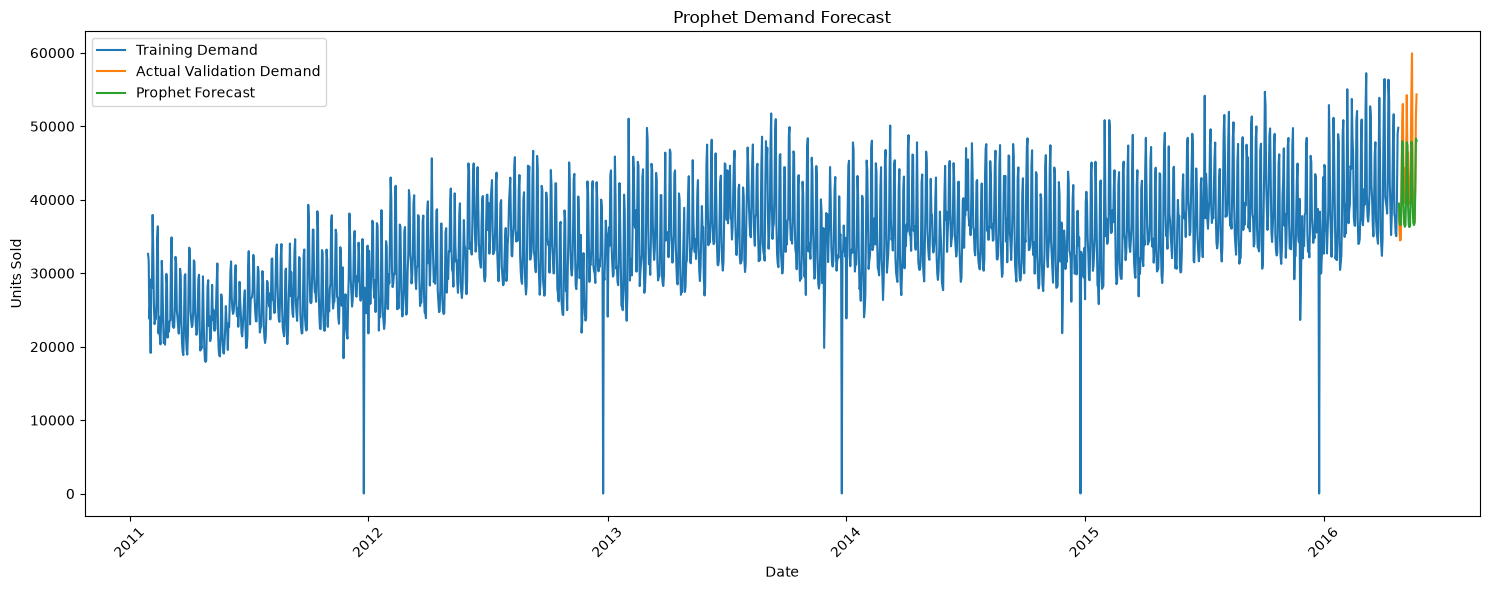

In [21]:
plt.figure(figsize=(15, 6))

plt.plot(
    train["date"],
    train["units_sold"],
    label="Training Demand"
)

plt.plot(
    validation["date"],
    validation["units_sold"],
    label="Actual Validation Demand"
)

plt.plot(
    prophet_validation["date"],
    prophet_validation["forecast"],
    label="Prophet Forecast"
)

plt.title("Prophet Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Advanced Demand Forecasting — LightGBM

This notebook develops a machine learning based demand forecasting model using LightGBM.

The model uses historical demand patterns and time-series features such as:
- Lag demand
- Rolling averages
- Day of week
- Month
- Year

A chronological 28-day validation period is used to evaluate forecasting performance.

In [23]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "lightgbm"
])

0

In [24]:
from lightgbm import LGBMRegressor

print("LightGBM imported successfully!")

LightGBM imported successfully!


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

from pathlib import Path

In [26]:
BASE_DIR = Path.cwd().parent

SALES_PATH = BASE_DIR / "data" / "raw" / "sales_train_evaluation.csv"

sales = pd.read_csv(SALES_PATH)

print("Sales data loaded successfully.")
print("Shape:", sales.shape)

Sales data loaded successfully.
Shape: (30490, 1947)


In [27]:
day_columns = [
    column for column in sales.columns
    if column.startswith("d_")
]

print("Number of daily columns:", len(day_columns))
print("First 5:", day_columns[:5])
print("Last 5:", day_columns[-5:])

Number of daily columns: 1941
First 5: ['d_1', 'd_2', 'd_3', 'd_4', 'd_5']
Last 5: ['d_1937', 'd_1938', 'd_1939', 'd_1940', 'd_1941']


In [28]:
sales["total_units"] = sales[day_columns].sum(axis=1)

top_series = sales.nlargest(
    50,
    "total_units"
).copy()

print("Top item-store series selected:", len(top_series))

print(
    top_series[
        ["item_id", "dept_id", "cat_id", "store_id", "state_id", "total_units"]
    ].head(10)
)

C:\Users\DELL-PC\AppData\Local\Temp\ipykernel_1180\1841787123.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  sales["total_units"] = sales[day_columns].sum(axis=1)


Top item-store series selected: 50
           item_id  dept_id cat_id store_id state_id  total_units
8412   FOODS_3_090  FOODS_3  FOODS     CA_3       CA       253859
18055  FOODS_3_586  FOODS_3  FOODS     TX_2       TX       195120
21104  FOODS_3_586  FOODS_3  FOODS     TX_3       TX       151862
8908   FOODS_3_586  FOODS_3  FOODS     CA_3       CA       136269
2314   FOODS_3_090  FOODS_3  FOODS     CA_1       CA       128855
29755  FOODS_3_090  FOODS_3  FOODS     WI_3       WI       123500
17559  FOODS_3_090  FOODS_3  FOODS     TX_2       TX       121275
20608  FOODS_3_090  FOODS_3  FOODS     TX_3       TX       116773
17721  FOODS_3_252  FOODS_3  FOODS     TX_2       TX       115613
15006  FOODS_3_586  FOODS_3  FOODS     TX_1       TX       114010


In [29]:
id_columns = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id"
]

top_series_long = top_series[
    id_columns + day_columns
].melt(
    id_vars=id_columns,
    var_name="d",
    value_name="units_sold"
)

print("Long-format dataset created.")
print("Shape:", top_series_long.shape)

Long-format dataset created.
Shape: (97050, 7)


In [30]:
calendar_path = BASE_DIR / "data" / "raw" / "calendar.csv"

calendar = pd.read_csv(calendar_path)

calendar["date"] = pd.to_datetime(calendar["date"])

print(calendar.shape)

(1969, 14)


In [31]:
top_series_long = top_series_long.merge(
    calendar[
        ["d", "date", "weekday", "wday", "month", "year"]
    ],
    on="d",
    how="left"
)

top_series_long = top_series_long.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

print(top_series_long.head())


       item_id  dept_id cat_id store_id state_id    d  units_sold       date  \
0  FOODS_2_360  FOODS_2  FOODS     WI_2       WI  d_1           0 2011-01-29   
1  FOODS_2_360  FOODS_2  FOODS     WI_2       WI  d_2           0 2011-01-30   
2  FOODS_2_360  FOODS_2  FOODS     WI_2       WI  d_3           0 2011-01-31   
3  FOODS_2_360  FOODS_2  FOODS     WI_2       WI  d_4           0 2011-02-01   
4  FOODS_2_360  FOODS_2  FOODS     WI_2       WI  d_5           0 2011-02-02   

     weekday  wday  month  year  
0   Saturday     1      1  2011  
1     Sunday     2      1  2011  
2     Monday     3      1  2011  
3    Tuesday     4      2  2011  
4  Wednesday     5      2  2011  


In [34]:
# Create time-series features

top_series_long = top_series_long.sort_values(
    ["item_id", "store_id", "date"]
).reset_index(drop=True)

# Lag features
top_series_long["lag_1"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .shift(1)
)

top_series_long["lag_7"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .shift(7)
)

top_series_long["lag_14"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .shift(14)
)

top_series_long["lag_28"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .shift(28)
)

# Rolling features
top_series_long["rolling_mean_7"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(7).mean()
    )
)

top_series_long["rolling_mean_28"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(28).mean()
    )
)

top_series_long["rolling_std_28"] = (
    top_series_long
    .groupby(["item_id", "store_id"])["units_sold"]
    .transform(
        lambda x: x.shift(1).rolling(28).std()
    )
)

print("Time-series features created successfully.")

Time-series features created successfully.


In [35]:
feature_columns = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28"
]

print(top_series_long[feature_columns].head(35))

    lag_1  lag_7  lag_14  lag_28  rolling_mean_7  rolling_mean_28  \
0     NaN    NaN     NaN     NaN             NaN              NaN   
1     0.0    NaN     NaN     NaN             NaN              NaN   
2     0.0    NaN     NaN     NaN             NaN              NaN   
3     0.0    NaN     NaN     NaN             NaN              NaN   
4     0.0    NaN     NaN     NaN             NaN              NaN   
5     0.0    NaN     NaN     NaN             NaN              NaN   
6     0.0    NaN     NaN     NaN             NaN              NaN   
7     0.0    0.0     NaN     NaN             0.0              NaN   
8     0.0    0.0     NaN     NaN             0.0              NaN   
9     0.0    0.0     NaN     NaN             0.0              NaN   
10    0.0    0.0     NaN     NaN             0.0              NaN   
11    0.0    0.0     NaN     NaN             0.0              NaN   
12    0.0    0.0     NaN     NaN             0.0              NaN   
13    0.0    0.0     NaN     NaN  

In [36]:
top_series_long["day_of_week"] = top_series_long["date"].dt.dayofweek
top_series_long["day_of_month"] = top_series_long["date"].dt.day
top_series_long["month_num"] = top_series_long["date"].dt.month
top_series_long["year_num"] = top_series_long["date"].dt.year

print("Calendar features created successfully.")

print(
    top_series_long[
        [
            "date",
            "units_sold",
            "lag_1",
            "lag_7",
            "lag_14",
            "lag_28",
            "rolling_mean_7",
            "rolling_mean_28"
        ]
    ].head(35)
)

Calendar features created successfully.
         date  units_sold  lag_1  lag_7  lag_14  lag_28  rolling_mean_7  \
0  2011-01-29           0    NaN    NaN     NaN     NaN             NaN   
1  2011-01-30           0    0.0    NaN     NaN     NaN             NaN   
2  2011-01-31           0    0.0    NaN     NaN     NaN             NaN   
3  2011-02-01           0    0.0    NaN     NaN     NaN             NaN   
4  2011-02-02           0    0.0    NaN     NaN     NaN             NaN   
5  2011-02-03           0    0.0    NaN     NaN     NaN             NaN   
6  2011-02-04           0    0.0    NaN     NaN     NaN             NaN   
7  2011-02-05           0    0.0    0.0     NaN     NaN             0.0   
8  2011-02-06           0    0.0    0.0     NaN     NaN             0.0   
9  2011-02-07           0    0.0    0.0     NaN     NaN             0.0   
10 2011-02-08           0    0.0    0.0     NaN     NaN             0.0   
11 2011-02-09           0    0.0    0.0     NaN     NaN     

In [37]:
model_data = top_series_long.dropna().copy()

print("Original rows:", len(top_series_long))
print("Rows after feature preparation:", len(model_data))
print("Missing values:", model_data.isnull().sum().sum())

Original rows: 97050
Rows after feature preparation: 95650
Missing values: 0


In [38]:
validation_days = 28

max_date = model_data["date"].max()

validation_start = (
    max_date - pd.Timedelta(days=validation_days - 1)
)

train_data = model_data[
    model_data["date"] < validation_start
].copy()

validation_data = model_data[
    model_data["date"] >= validation_start
].copy()

print("Training period:")
print(train_data["date"].min(), "to", train_data["date"].max())

print("\nValidation period:")
print(validation_data["date"].min(), "to", validation_data["date"].max())

print("\nTraining rows:", len(train_data))
print("Validation rows:", len(validation_data))

Training period:
2011-02-26 00:00:00 to 2016-04-24 00:00:00

Validation period:
2016-04-25 00:00:00 to 2016-05-22 00:00:00

Training rows: 94250
Validation rows: 1400


In [39]:
features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_28",
    "rolling_std_28",
    "day_of_week",
    "day_of_month",
    "month_num",
    "year_num"
]

X_train = train_data[features]
y_train = train_data["units_sold"]

X_validation = validation_data[features]
y_validation = validation_data["units_sold"]

print("Number of features:", len(features))
print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)

Number of features: 11
Training shape: (94250, 11)
Validation shape: (1400, 11)


In [40]:
lgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(
    X_train,
    y_train
)

print("LightGBM model trained successfully.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.070488 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1844
[LightGBM] [Info] Number of data points in the train set: 94250, number of used features: 11
[LightGBM] [Info] Start training from score 43.490568
LightGBM model trained successfully.


In [41]:
lgbm_predictions = lgbm_model.predict(
    X_validation
)

lgbm_predictions = np.maximum(
    lgbm_predictions,
    0
)

print("Predictions generated.")
print("First 10 predictions:")
print(lgbm_predictions[:10])

Predictions generated.
First 10 predictions:
[33.94646281 38.16976202 35.56479637 52.18712854 51.32244374 58.34446809
 40.48003397 48.92656282 63.52371873 61.0260344 ]


In [42]:
lgbm_mae = mean_absolute_error(
    y_validation,
    lgbm_predictions
)

lgbm_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        lgbm_predictions
    )
)

lgbm_mape = np.mean(
    np.abs(
        (y_validation.values - lgbm_predictions)
        /
        np.where(
            y_validation.values == 0,
            1,
            y_validation.values
        )
    )
) * 100

print("LightGBM Results")
print("=" * 40)
print("MAE :", lgbm_mae)
print("RMSE:", lgbm_rmse)
print("MAPE:", lgbm_mape)

LightGBM Results
MAE : 9.679731065171366
RMSE: 14.398423111097351
MAPE: 74.09516023386242


In [43]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": lgbm_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

print(feature_importance)

            Feature  Importance
0             lag_1        2409
1             lag_7        1809
3            lag_28        1616
2            lag_14        1521
8      day_of_month        1485
4    rolling_mean_7        1410
6    rolling_std_28        1213
5   rolling_mean_28        1089
7       day_of_week        1008
9         month_num        1003
10         year_num         437


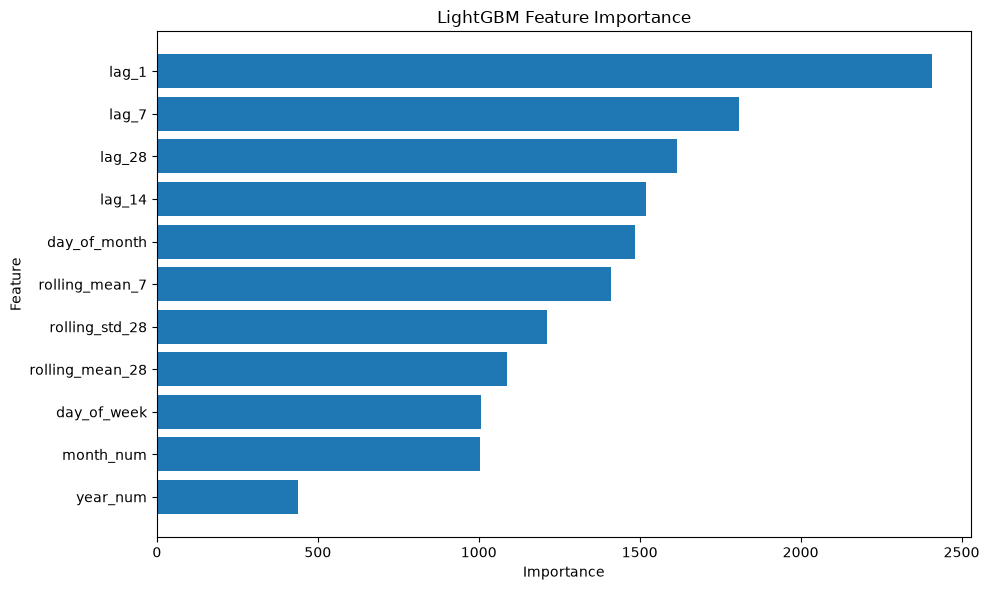

In [44]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("LightGBM Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [46]:
models_dir = BASE_DIR / "models"

models_dir.mkdir(
    exist_ok=True
)

In [47]:
import joblib

model_path = models_dir / "lightgbm_demand_model.joblib"

joblib.dump(
    lgbm_model,
    model_path
)

print("Model saved successfully:")
print(model_path)

Model saved successfully:
c:\Users\DELL-PC\Desktop\retail-demand-forecasting\models\lightgbm_demand_model.joblib


In [48]:
results_dir = BASE_DIR / "reports" / "model_results"

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

feature_importance_path = (
    results_dir / "lightgbm_feature_importance.csv"
)

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("Feature importance saved.")

Feature importance saved.


In [50]:
import pandas as pd
from pathlib import Path

BASE_DIR = Path.cwd().parent

results_dir = BASE_DIR / "reports" / "model_results"

baseline_path = results_dir / "baseline_results.csv"

baseline_results = pd.read_csv(baseline_path)

print("Baseline results loaded successfully.")
print(baseline_results)

Baseline results loaded successfully.
                  Model          MAE         RMSE       MAPE
0        Naive Forecast  7890.571429  8817.170059  19.395964
1  7-Day Moving Average  5506.387755  7385.367183  11.620051


In [53]:
forecast_results = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "7-Day Moving Average",
        "Prophet",
        "LightGBM"
    ],
    "MAE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "MAE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "MAE"
        ].iloc[0],

        prophet_mae,
        lgbm_mae
    ],
    "RMSE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "RMSE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "RMSE"
        ].iloc[0],

        prophet_rmse,
        lgbm_rmse
    ],
    "MAPE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "MAPE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "MAPE"
        ].iloc[0],

        prophet_mape,
        lgbm_mape
    ]
})

forecast_results

,Model,MAE,RMSE,MAPE
0,Naive Forecast,7890.571429,8817.170059,19.395964
1,7-Day Moving Average,5506.387755,7385.367183,11.620051
2,Prophet,3797.620721,4617.906289,8.203196
3,LightGBM,9.679731,14.398423,74.095160


In [54]:
forecast_results_path = (
    results_dir / "forecast_model_comparison.csv"
)

forecast_results.to_csv(
    forecast_results_path,
    index=False
)

print("Forecast model comparison saved successfully.")
print(forecast_results)

Forecast model comparison saved successfully.
                  Model          MAE         RMSE       MAPE
0        Naive Forecast  7890.571429  8817.170059  19.395964
1  7-Day Moving Average  5506.387755  7385.367183  11.620051
2               Prophet  3797.620721  4617.906289   8.203196
3              LightGBM     9.679731    14.398423  74.095160


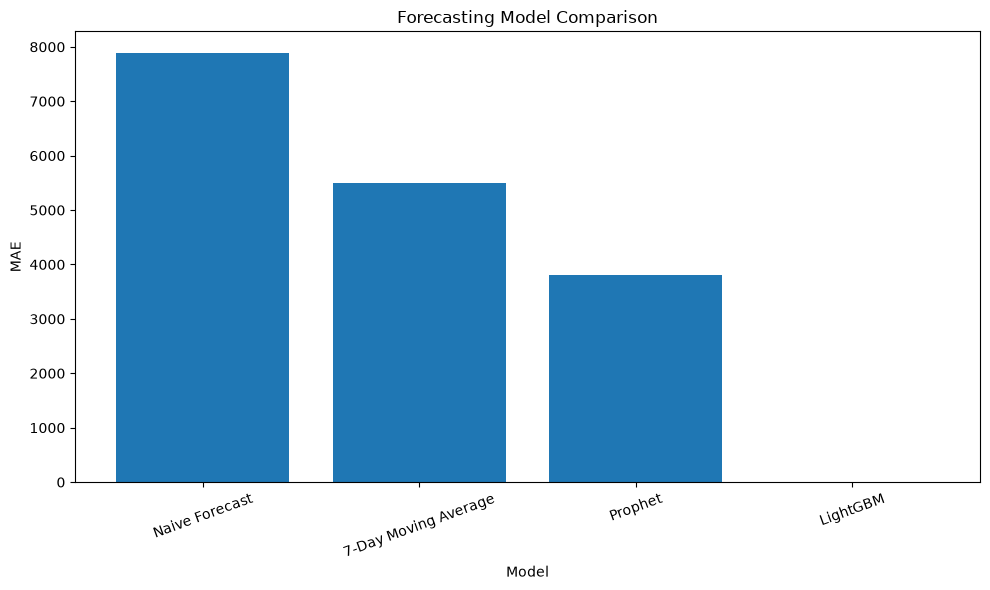

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.bar(
    forecast_results["Model"],
    forecast_results["MAE"]
)

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Forecasting Model Comparison")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## Recursive 28-Day LightGBM Forecast

The LightGBM model is used to generate a multi-step demand forecast.

Predictions are generated sequentially so that future predictions do not use actual validation demand values.

In [56]:
def create_features_for_prediction(history):
    """
    Create the same time-series features used during model training
    for the next prediction point.
    """

    features = {
        "lag_1": history.iloc[-1],
        "lag_7": history.iloc[-7],
        "lag_14": history.iloc[-14],
        "lag_28": history.iloc[-28],

        "rolling_mean_7": history.iloc[-7:].mean(),

        "rolling_mean_28": history.iloc[-28:].mean(),

        "rolling_std_28": history.iloc[-28:].std()
    }

    return features

In [57]:
test_series = (
    top_series_long[
        (top_series_long["item_id"] == top_series_long["item_id"].iloc[0]) &
        (top_series_long["store_id"] == top_series_long["store_id"].iloc[0])
    ]
    .sort_values("date")
)

test_history = test_series["units_sold"].dropna().reset_index(drop=True)

test_features = create_features_for_prediction(test_history)

print("Test features:")
print(test_features)

Test features:
{'lag_1': np.int64(20), 'lag_7': np.int64(66), 'lag_14': np.int64(117), 'lag_28': np.int64(38), 'rolling_mean_7': np.float64(34.57142857142857), 'rolling_mean_28': np.float64(57.75), 'rolling_std_28': np.float64(30.18292993165606)}


In [58]:
forecast_horizon = 28

series_keys = (
    top_series[
        ["item_id", "store_id"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print("Number of item-store series:", len(series_keys))
print("Forecast horizon:", forecast_horizon, "days")

Number of item-store series: 50
Forecast horizon: 28 days


In [60]:
def recursive_forecast_series(
    model,
    history,
    forecast_dates
):
    """
    Generate recursive multi-step forecasts.
    """

    history = list(history)

    predictions = []

    for forecast_date in forecast_dates:

        feature_values = {
            "lag_1": history[-1],
            "lag_7": history[-7],
            "lag_14": history[-14],
            "lag_28": history[-28],

            "rolling_mean_7": np.mean(
                history[-7:]
            ),

            "rolling_mean_28": np.mean(
                history[-28:]
            ),

            "rolling_std_28": np.std(
                history[-28:],
                ddof=1
            ),

            "day_of_week": forecast_date.dayofweek,

            "day_of_month": forecast_date.day,

            "month_num": forecast_date.month,

            "year_num": forecast_date.year
        }

        X_future = pd.DataFrame(
            [feature_values]
        )

        prediction = model.predict(
            X_future[features]
        )[0]

        prediction = max(
            0,
            prediction
        )

        predictions.append(
            prediction
        )

        # Add prediction to history
        history.append(
            prediction
        )

    return predictions

In [61]:
recursive_forecasts = []

for _, row in series_keys.iterrows():

    item_id = row["item_id"]
    store_id = row["store_id"]

    series = top_series_long[
        (top_series_long["item_id"] == item_id) &
        (top_series_long["store_id"] == store_id)
    ].sort_values("date")

    history = series[
        series["date"] < validation_start
    ]["units_sold"].tolist()

    forecast_dates = pd.date_range(
        start=validation_start,
        periods=forecast_horizon,
        freq="D"
    )

    predictions = recursive_forecast_series(
        lgbm_model,
        history,
        forecast_dates
    )

    for date, prediction in zip(
        forecast_dates,
        predictions
    ):

        recursive_forecasts.append({
            "item_id": item_id,
            "store_id": store_id,
            "date": date,
            "forecast_units": prediction
        })

recursive_forecast_df = pd.DataFrame(
    recursive_forecasts
)

print("Recursive forecasting completed.")
print("Shape:", recursive_forecast_df.shape)

Recursive forecasting completed.
Shape: (1400, 4)


In [62]:
recursive_forecast_df.head(20)

,item_id,store_id,date,forecast_units
0,FOODS_3_090,CA_3,2016-04-25,85.326214
1,FOODS_3_090,CA_3,2016-04-26,79.701673
2,FOODS_3_090,CA_3,2016-04-27,80.318941
3,FOODS_3_090,CA_3,2016-04-28,85.978889
4,FOODS_3_090,CA_3,2016-04-29,115.257539
5,FOODS_3_090,CA_3,2016-04-30,137.822698
6,FOODS_3_090,CA_3,2016-05-01,138.840826
7,FOODS_3_090,CA_3,2016-05-02,94.373100
8,FOODS_3_090,CA_3,2016-05-03,93.052662
9,FOODS_3_090,CA_3,2016-05-04,93.276192


In [63]:
print(
    recursive_forecast_df["forecast_units"].describe()
)

count    1400.000000
mean       41.729559
std        19.893830
min         0.000000
25%        28.114367
50%        37.285316
75%        50.559563
max       153.254321
Name: forecast_units, dtype: float64


In [64]:
print(
    "Missing values:",
    recursive_forecast_df.isnull().sum().sum()
)

print(
    "Negative forecasts:",
    (recursive_forecast_df["forecast_units"] < 0).sum()
)

Missing values: 0
Negative forecasts: 0


In [65]:
actual_validation = top_series_long[
    top_series_long["date"] >= validation_start
][
    [
        "item_id",
        "store_id",
        "date",
        "units_sold"
    ]
].copy()

comparison = recursive_forecast_df.merge(
    actual_validation,
    on=["item_id", "store_id", "date"],
    how="left"
)

print("Comparison shape:", comparison.shape)
print(comparison.head())

Comparison shape: (1400, 5)
       item_id store_id       date  forecast_units  units_sold
0  FOODS_3_090     CA_3 2016-04-25       85.326214         133
1  FOODS_3_090     CA_3 2016-04-26       79.701673         117
2  FOODS_3_090     CA_3 2016-04-27       80.318941         113
3  FOODS_3_090     CA_3 2016-04-28       85.978889          99
4  FOODS_3_090     CA_3 2016-04-29      115.257539         196


In [66]:
recursive_mae = mean_absolute_error(
    comparison["units_sold"],
    comparison["forecast_units"]
)

recursive_rmse = np.sqrt(
    mean_squared_error(
        comparison["units_sold"],
        comparison["forecast_units"]
    )
)

recursive_mape = np.mean(
    np.abs(
        (
            comparison["units_sold"]
            -
            comparison["forecast_units"]
        )
        /
        np.where(
            comparison["units_sold"] == 0,
            1,
            comparison["units_sold"]
        )
    )
) * 100

print("Recursive LightGBM Results")
print("=" * 45)
print("MAE :", recursive_mae)
print("RMSE:", recursive_rmse)
print("MAPE:", recursive_mape)

Recursive LightGBM Results
MAE : 10.906828366491716
RMSE: 15.5045671502109
MAPE: 173.34974453350074


In [67]:
recursive_forecast_path = (
    results_dir /
    "recursive_lightgbm_forecast.csv"
)

recursive_forecast_df.to_csv(
    recursive_forecast_path,
    index=False
)

print("Recursive forecast saved:")
print(recursive_forecast_path)

Recursive forecast saved:
c:\Users\DELL-PC\Desktop\retail-demand-forecasting\reports\model_results\recursive_lightgbm_forecast.csv


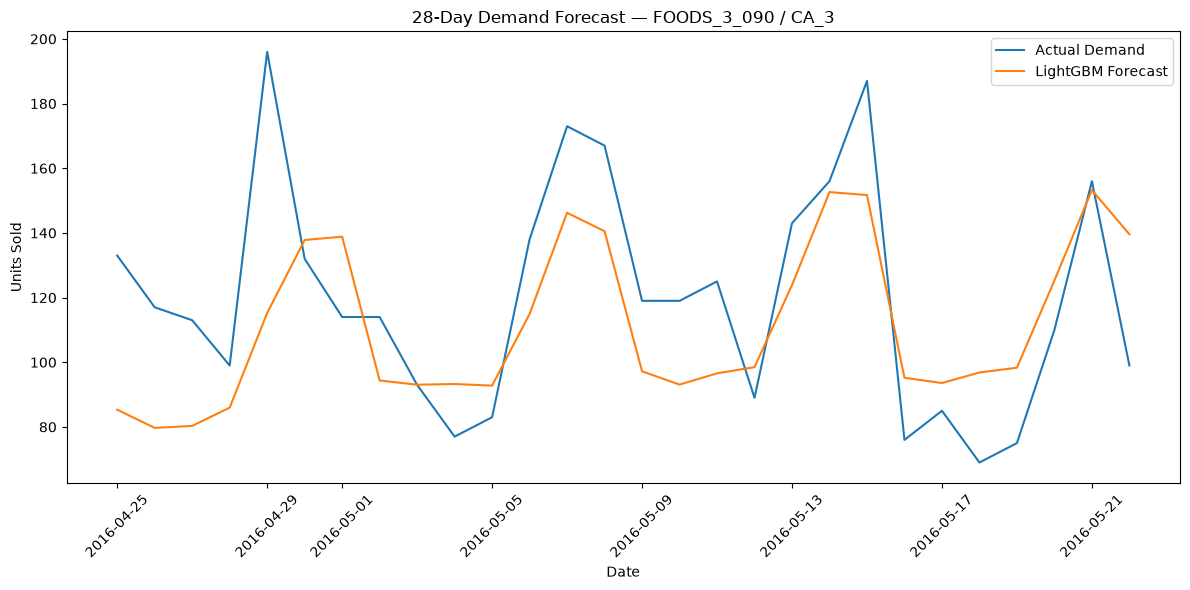

In [68]:
example_item = series_keys.iloc[0]["item_id"]
example_store = series_keys.iloc[0]["store_id"]

example_actual = comparison[
    (comparison["item_id"] == example_item) &
    (comparison["store_id"] == example_store)
]

plt.figure(figsize=(12, 6))

plt.plot(
    example_actual["date"],
    example_actual["units_sold"],
    label="Actual Demand"
)

plt.plot(
    example_actual["date"],
    example_actual["forecast_units"],
    label="LightGBM Forecast"
)

plt.xlabel("Date")
plt.ylabel("Units Sold")

plt.title(
    f"28-Day Demand Forecast — {example_item} / {example_store}"
)

plt.legend()

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [69]:
forecast_results_final = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "7-Day Moving Average",
        "Prophet",
        "LightGBM Feature Validation",
        "LightGBM Recursive"
    ],
    "MAE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "MAE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "MAE"
        ].iloc[0],

        prophet_mae,

        lgbm_mae,

        recursive_mae
    ],
    "RMSE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "RMSE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "RMSE"
        ].iloc[0],

        prophet_rmse,

        lgbm_rmse,

        recursive_rmse
    ],
    "MAPE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "MAPE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "MAPE"
        ].iloc[0],

        prophet_mape,

        lgbm_mape,

        recursive_mape
    ]
})

print(forecast_results_final)

                         Model          MAE         RMSE        MAPE
0               Naive Forecast  7890.571429  8817.170059   19.395964
1         7-Day Moving Average  5506.387755  7385.367183   11.620051
2                      Prophet  3797.620721  4617.906289    8.203196
3  LightGBM Feature Validation     9.679731    14.398423   74.095160
4           LightGBM Recursive    10.906828    15.504567  173.349745


In [70]:
forecast_results_final = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "7-Day Moving Average",
        "Prophet",
        "LightGBM Feature Validation",
        "LightGBM Recursive"
    ],
    "MAE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "MAE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "MAE"
        ].iloc[0],

        prophet_mae,

        lgbm_mae,

        recursive_mae
    ],
    "RMSE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "RMSE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "RMSE"
        ].iloc[0],

        prophet_rmse,

        lgbm_rmse,

        recursive_rmse
    ],
    "MAPE": [
        baseline_results.loc[
            baseline_results["Model"] == "Naive Forecast",
            "MAPE"
        ].iloc[0],

        baseline_results.loc[
            baseline_results["Model"] == "7-Day Moving Average",
            "MAPE"
        ].iloc[0],

        prophet_mape,

        lgbm_mape,

        recursive_mape
    ]
})

print(forecast_results_final)

                         Model          MAE         RMSE        MAPE
0               Naive Forecast  7890.571429  8817.170059   19.395964
1         7-Day Moving Average  5506.387755  7385.367183   11.620051
2                      Prophet  3797.620721  4617.906289    8.203196
3  LightGBM Feature Validation     9.679731    14.398423   74.095160
4           LightGBM Recursive    10.906828    15.504567  173.349745


In [71]:
final_results_path = (
    results_dir /
    "final_forecast_model_comparison.csv"
)

forecast_results_final.to_csv(
    final_results_path,
    index=False
)

print("Final forecasting comparison saved.")

Final forecasting comparison saved.


In [72]:
best_model = forecast_results_final.loc[
    forecast_results_final["MAE"].idxmin()
]

print("Best forecasting model:")
print(best_model)

Best forecasting model:
Model    LightGBM Feature Validation
MAE                         9.679731
RMSE                       14.398423
MAPE                        74.09516
Name: 3, dtype: object
